# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [147]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

In [148]:
df_chembl = pd.read_csv("chembl_200-500_10k.csv")
df_pubchem = pd.read_csv("pubchem_antibiotics.csv")

Data cleaning

In [149]:
df_chembl.head()

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Heavy Atoms,Np Likeness Score,Molecular Formula,SMILES,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,25.0,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,25.0,-0.90,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']"
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,30.0,-1.12,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394']
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,36.0,-1.28,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,31.0,-0.62,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-..."


In [150]:
df_pubchem.head()

,Compound_CID,Name,Synonyms,Molecular_Formula,InChI,Smiles,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808


In [151]:
df_chembl.columns = df_chembl.columns.str.lower().str.replace('[^a-z0-9]+', '_', regex=True).str.strip('_') # standardizing column names
df_chembl

,chembl_id,name,synonyms,type,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,...,heavy_atoms,np_likeness_score,molecular_formula,smiles,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,25.0,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,25.0,-0.90,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']"
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,30.0,-1.12,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394']
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,36.0,-1.28,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,31.0,-0.62,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CHEMBL1877743,NaN,NaN,Small molecule,NaN,420.90,3.0,3.0,5.36,69.04,...,30.0,-1.71,C23H21ClN4O2,CC(C)COc1ccc(C(=O)Nc2cc3nn(-c4ccccc4)nc3cc2Cl)cc1,ULVAZAAEJIEJOT-UHFFFAOYSA-N,InChI=1S/C23H21ClN4O2/c1-15(2)14-30-18-10-8-16...,False,-1,['SID24276249'],['SID24276249']
9996,CHEMBL1410323,NaN,NaN,Small molecule,NaN,347.68,14.0,18.0,2.73,84.23,...,23.0,-1.72,C13H9ClF3N3O3,Cc1nc(C(=O)NNC(=O)c2cccc(Cl)c2)c(C(F)(F)F)o1,SKTQWXALPWUTCU-UHFFFAOYSA-N,InChI=1S/C13H9ClF3N3O3/c1-6-18-9(10(23-6)13(15...,False,-1,['SID26730806'],['SID26730806']
9997,CHEMBL1565837,NaN,NaN,Small molecule,NaN,248.35,12.0,19.0,3.24,52.89,...,17.0,-2.46,C13H16N2OS,CCCC(=O)Nc1sc2c(c1C#N)CCCC2,KLLJJRPAXNCRMB-UHFFFAOYSA-N,InChI=1S/C13H16N2OS/c1-2-5-12(16)15-13-10(8-14...,False,-1,['SID856609'],['SID856609']
9998,CHEMBL1234490,TERBUTRYNE,NaN,Small molecule,NaN,241.36,5.0,5.0,2.24,62.73,...,16.0,-1.52,C10H19N5S,CCNc1nc(NC(C)(C)C)nc(SC)n1,IROINLKCQGIITA-UHFFFAOYSA-N,"InChI=1S/C10H19N5S/c1-6-11-7-12-8(15-10(2,3)4)...",False,-1,"['SID144213458', 'SID144209280', 'SID26757718'...","['SID144213458', 'SID144209280', 'SID26757718'..."


In [152]:
df_pubchem.columns = df_pubchem.columns.str.lower().str.replace('[^a-z0-9]+', '_', regex=True).str.strip('_') # standardizing column names
df_pubchem

,compound_cid,name,synonyms,molecular_formula,inchi,smiles,inchikey,iupac_name,mesh_headings,annotation_content,...,defined_atom_stereo_count,undefined_atom_stereo_count,total_bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,linked_pubchem_literature_count,linked_pubchem_patent_count,linked_pubchem_patent_family_count,annotation_type_count,create_date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2353,131634493,Zoptarelin Doxorubicin Acetate,Zoptarelin doxorubicin acetate|4IA03SIO30|Zopt...,C97H129N19O32,InChI=1S/C91H117N19O26.3C2H4O2/c1-44(2)31-58(8...,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,XBNFJFHLGRBGTL-KICSVHBJSA-N,"acetic acid;[2-[(2S,4S)-4-[(2R,4S,5S,6S)-4-ami...","LHRH, lysine(6)-doxorubicin",Classification|Literature|Patents,...,15,0,0,0,0,42,6,5,3,20171017
2354,131750213,Contezolid Acefosamil,Contezolid acefosamil|1807365-35-0|MRX-4 SODIU...,C20H17F3N4NaO8P,"InChI=1S/C20H18F3N4O8P.Na/c1-11(28)35-36(31,32...",CC(=O)OP(=O)(N(C[C@H]1CN(C(=O)O1)C2=CC(=C(C(=C...,JANNTEAGZXJITO-BTQNPOSSSA-M,"sodium acetyloxy-[1,2-oxazol-3-yl-[[(5R)-2-oxo...",NaN,Biological Test Results|Interactions and Pathw...,...,1,0,0,0,0,8,18,9,8,20171119
2355,131750285,"(7S,9S)-7-[(2S,4R,5R,6R)-4-amino-6-methyl-5-[(...",NaN,C32H37NO12,InChI=1S/C32H37NO12/c1-14-31(45-21-8-3-4-9-42-...,C[C@@H]1[C@@H]([C@@H](C[C@H](O1)O[C@H]2C[C@@](...,KMSKQZKKOZQFFG-CBFOJMSHSA-N,"(7S,9S)-7-[(2S,4R,5R,6R)-4-amino-6-methyl-5-[(...",NaN,NaN,...,7,0,0,0,0,0,0,0,0,20171121
2356,131750203,Chromomycins,Chromomycins,C57H82O26,InChI=1S/C57H82O26/c1-21-34(79-40-19-37(53(26(...,C[C@@H]1[C@H]([C@@H](C[C@@H](O1)O[C@H]2[C@@H](...,ZYVSOIYQKUDENJ-ASUJBHBQSA-N,"[(2R,3R,4R,6R)-6-[[(6S,7S)-6-[(2S,4R,5R,6R)-4-...",NaN,Classification|Literature|Patents|Toxicity,...,24,1,0,0,0,176,7416,2116,4,20171119


In [153]:
df_chembl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   chembl_id           10000 non-null  object 
 1   name                182 non-null    object 
 2   synonyms            82 non-null     object 
 3   type                10000 non-null  object 
 4   max_phase           75 non-null     float64
 5   molecular_weight    10000 non-null  float64
 6   targets             9593 non-null   float64
 7   bioactivities       9593 non-null   float64
 8   alogp               9946 non-null   float64
 9   polar_surface_area  9946 non-null   float64
 10  hba                 9946 non-null   float64
 11  hbd                 9946 non-null   float64
 12  ro5_violations      9946 non-null   float64
 13  rotatable_bonds     9946 non-null   float64
 14  passes_ro3          9946 non-null   object 
 15  qed_weighted        9946 non-null   float64
 16  aroma

In [154]:
df_pubchem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   compound_cid                        2358 non-null   int64  
 1   name                                2358 non-null   object 
 2   synonyms                            2330 non-null   object 
 3   molecular_formula                   2358 non-null   object 
 4   inchi                               2358 non-null   object 
 5   smiles                              2358 non-null   object 
 6   inchikey                            2358 non-null   object 
 7   iupac_name                          2348 non-null   object 
 8   mesh_headings                       1124 non-null   object 
 9   annotation_content                  2225 non-null   object 
 10  linked_bioassays                    1093 non-null   object 
 11  data_source                         2358 no

In [155]:
df_chembl.describe()

,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,hba,hbd,ro5_violations,rotatable_bonds,qed_weighted,aromatic_rings,inorganic_flag,heavy_atoms,np_likeness_score,orphan
count,75.000000,10000.000000,9593.000000,9593.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,9946.000000,10000.000000,9946.000000,9946.000000,10000.000000
mean,2.026667,367.632781,6.980298,10.977692,3.293754,72.823139,4.775990,1.357631,0.134627,4.922180,0.613163,2.359240,-0.992500,25.737181,-0.921939,-0.992400
std,1.314918,71.308667,14.499846,72.107042,1.570448,30.772358,1.843906,1.153433,0.343983,2.604628,0.182504,1.091465,0.086281,5.227196,1.015270,0.087994
min,-1.000000,200.280000,1.000000,1.000000,-5.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,-1.000000,8.000000,-4.070000,-1.000000
25%,2.000000,315.502500,1.000000,2.000000,2.340000,51.100000,3.000000,1.000000,0.000000,3.000000,0.480000,2.000000,-1.000000,22.000000,-1.590000,-1.000000
50%,2.000000,368.455000,3.000000,5.000000,3.335000,69.910000,5.000000,1.000000,0.000000,5.000000,0.620000,2.000000,-1.000000,26.000000,-1.080000,-1.000000
75%,3.000000,423.525000,7.000000,10.000000,4.290000,91.287500,6.000000,2.000000,0.000000,6.000000,0.760000,3.000000,-1.000000,30.000000,-0.460000,-1.000000
max,4.000000,499.700000,613.000000,5992.000000,9.930000,258.840000,16.000000,8.000000,2.000000,23.000000,0.950000,6.000000,0.000000,38.000000,4.110000,1.000000


In [156]:
df_pubchem.describe()

,compound_cid,molecular_weight,polar_area,complexity,xlogp,heavy_atom_count,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,exact_mass,...,defined_atom_stereo_count,undefined_atom_stereo_count,total_bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,linked_pubchem_literature_count,linked_pubchem_patent_count,linked_pubchem_patent_family_count,annotation_type_count,create_date
count,2.358000e+03,2358.000000,2358.000000,2358.000000,1905.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,...,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2.358000e+03
mean,3.287431e+07,661.647590,227.031293,1169.944444,0.961995,45.955047,6.104750,12.417303,8.997880,661.124215,...,5.918999,2.529686,0.814673,0.715437,0.099237,1329.260814,5149.486429,1420.523325,6.229856,2.008519e+07
std,4.844780e+07,396.047313,164.974911,831.344101,3.740470,27.725970,5.913143,7.577051,8.422624,395.802160,...,6.683319,5.229701,1.589103,1.487333,0.602913,6876.501858,15182.253531,4224.227155,4.539714,5.056542e+04
min,3.200000e+02,99.090000,3.200000,38.000000,-16.700000,7.000000,0.000000,1.000000,0.000000,99.032028,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.004092e+07
25%,1.962080e+05,405.300000,128.000000,647.000000,-1.100000,28.000000,2.000000,7.000000,4.000000,404.219879,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,2.005081e+07
50%,6.450115e+06,544.550000,193.000000,944.000000,1.300000,38.000000,4.000000,11.000000,7.000000,543.775238,...,3.500000,0.000000,0.000000,0.000000,0.000000,6.000000,48.000000,18.000000,5.000000,2.006043e+07
75%,5.468076e+07,814.000000,261.000000,1460.000000,3.400000,58.000000,7.000000,15.000000,11.000000,813.451050,...,9.000000,2.000000,1.000000,1.000000,0.000000,126.750000,1592.000000,482.250000,9.000000,2.011123e+07
max,1.778574e+08,3545.100000,1690.000000,8160.000000,18.600000,243.000000,58.000000,63.000000,67.000000,3543.581543,...,37.000000,33.000000,14.000000,14.000000,10.000000,132224.000000,142293.000000,40785.000000,20.000000,2.026013e+07


In [157]:
df_chembl.duplicated().sum()

np.int64(0)

In [158]:
df_pubchem.duplicated().sum()

np.int64(0)

In [159]:
df_chembl.isna().sum()

chembl_id                0
name                  9818
synonyms              9918
type                     0
max_phase             9925
molecular_weight         0
targets                407
bioactivities          407
alogp                   54
polar_surface_area      54
hba                     54
hbd                     54
ro5_violations          54
rotatable_bonds         54
passes_ro3              54
qed_weighted            54
aromatic_rings          54
structure_type           0
inorganic_flag           0
heavy_atoms             54
np_likeness_score       54
molecular_formula        0
smiles                   7
inchi_key                7
inchi                    7
withdrawn_flag           0
orphan                   0
records_key            376
records_name           376
dtype: int64

In [160]:
df_pubchem.isna().sum()

compound_cid                             0
name                                     0
synonyms                                28
molecular_formula                        0
inchi                                    0
smiles                                   0
inchikey                                 0
iupac_name                              10
mesh_headings                         1234
annotation_content                     133
linked_bioassays                      1265
data_source                              0
data_source_category                     0
tagged_by_pubchem                      925
molecular_weight                         0
polar_area                               0
complexity                               0
xlogp                                  453
heavy_atom_count                         0
h_bond_donor_count                       0
h_bond_acceptor_count                    0
rotatable_bond_count                     0
exact_mass                               0
monoisotopi

In [161]:
df_chembl = df_chembl.drop("chembl_id", axis=1)
df_chembl = df_chembl.drop("name", axis=1)
df_chembl = df_chembl.drop("synonyms", axis=1)
df_chembl = df_chembl.drop("type", axis=1)
df_chembl = df_chembl.drop("max_phase", axis=1)
df_chembl = df_chembl.drop("inchi_key", axis=1)
df_chembl = df_chembl.drop("inchi", axis=1)
df_chembl = df_chembl.drop("withdrawn_flag", axis=1)
df_chembl = df_chembl.drop("orphan", axis=1)
df_chembl = df_chembl.drop("records_key", axis=1)
df_chembl = df_chembl.drop("records_name", axis=1)
df_chembl = df_chembl.drop("molecular_formula", axis=1)

In [162]:
df_chembl.head()

,molecular_weight,targets,bioactivities,alogp,polar_surface_area,hba,hbd,ro5_violations,rotatable_bonds,passes_ro3,qed_weighted,aromatic_rings,structure_type,inorganic_flag,heavy_atoms,np_likeness_score,smiles
0,361.47,2.0,2.0,1.96,84.66,7.0,2.0,0.0,8.0,N,0.55,2.0,MOL,-1,25.0,-0.79,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O
1,339.35,4.0,4.0,2.33,110.62,7.0,2.0,0.0,3.0,N,0.88,2.0,MOL,-1,25.0,-0.90,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1
2,417.54,2.0,2.0,6.02,92.93,5.0,3.0,1.0,4.0,N,0.38,4.0,MOL,-1,30.0,-1.12,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...
3,487.61,3.0,9.0,4.12,77.07,8.0,1.0,0.0,5.0,N,0.58,3.0,MOL,-1,36.0,-1.28,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...
4,426.56,1.0,1.0,3.58,70.84,6.0,1.0,0.0,4.0,N,0.81,2.0,MOL,-1,31.0,-0.62,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...


In [163]:
df_pubchem = df_pubchem.drop("compound_cid", axis=1)
df_pubchem = df_pubchem.drop("name", axis=1)
df_pubchem = df_pubchem.drop("synonyms", axis=1)
df_pubchem = df_pubchem.drop("molecular_formula", axis=1)
df_pubchem = df_pubchem.drop("inchi", axis=1)
df_pubchem = df_pubchem.drop("inchikey", axis=1)
df_pubchem = df_pubchem.drop("iupac_name", axis=1)
df_pubchem = df_pubchem.drop("mesh_headings", axis=1)
df_pubchem = df_pubchem.drop("annotation_content", axis=1)
df_pubchem = df_pubchem.drop("linked_bioassays", axis=1)
df_pubchem = df_pubchem.drop("data_source", axis=1)
df_pubchem = df_pubchem.drop("data_source_category", axis=1)
df_pubchem = df_pubchem.drop("tagged_by_pubchem", axis=1)
df_pubchem = df_pubchem.drop("create_date", axis=1)
df_pubchem = df_pubchem.drop("annotation_type_count", axis=1)
df_pubchem = df_pubchem.drop("linked_pubchem_patent_family_count", axis=1)
df_pubchem = df_pubchem.drop("linked_pubchem_patent_count", axis=1)
df_pubchem = df_pubchem.drop("linked_pubchem_literature_count", axis=1)
df_pubchem = df_pubchem.drop("undefined_bond_stereo_count", axis=1)
df_pubchem = df_pubchem.drop("defined_bond_stereo_count", axis=1)
df_pubchem = df_pubchem.drop("total_bond_stereo_count", axis=1)
df_pubchem = df_pubchem.drop("undefined_atom_stereo_count", axis=1)
df_pubchem = df_pubchem.drop("defined_atom_stereo_count", axis=1)
df_pubchem = df_pubchem.drop("total_atom_stereo_count", axis=1)


In [164]:
df_pubchem.head()

,smiles,molecular_weight,polar_area,complexity,xlogp,heavy_atom_count,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,exact_mass,monoisotopic_mass,charge,covalent_unit_count,isotopic_atom_count
0,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,1313.4,459.0,2800,0.7,90,15,22,3,1311.137695,1311.137695,0,1,0
1,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,323.4,96.0,511,0.3,23,2,5,7,323.173279,323.173279,0,1,0
2,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,412.4,212.0,741,0.0,27,3,11,7,412.014740,412.014740,0,1,0
3,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,1157.3,273.0,2130,6.1,82,6,22,15,1156.593018,1156.593018,0,1,0
4,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,370.4,119.0,544,1.5,27,2,8,7,370.116486,370.116486,0,1,0


In [165]:
def standardize_smiles(smiles):
    normalizer = Normalizer()
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            standardized_mol = normalizer.normalize(mol)
            return Chem.MolToSmiles(standardized_mol)
        else:
            return None
    except:
        return None
    
df_chembl['smiles'] = df_chembl['smiles'].apply(standardize_smiles)
df_pubchem['smiles'] = df_pubchem['smiles'].apply(standardize_smiles)

[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing Normalizer
[20:05:09] Running Normalizer
[20:05:09] Initializing N

In [166]:
# removing any rows with invalid SMILES
df_chembl = df_chembl.dropna(subset=['smiles'])
df_pubchem = df_pubchem.dropna(subset=['smiles'])

In [167]:
df_chembl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecular_weight    9993 non-null   float64
 1   targets             9589 non-null   float64
 2   bioactivities       9589 non-null   float64
 3   alogp               9946 non-null   float64
 4   polar_surface_area  9946 non-null   float64
 5   hba                 9946 non-null   float64
 6   hbd                 9946 non-null   float64
 7   ro5_violations      9946 non-null   float64
 8   rotatable_bonds     9946 non-null   float64
 9   passes_ro3          9946 non-null   object 
 10  qed_weighted        9946 non-null   float64
 11  aromatic_rings      9946 non-null   float64
 12  structure_type      9993 non-null   object 
 13  inorganic_flag      9993 non-null   int64  
 14  heavy_atoms         9946 non-null   float64
 15  np_likeness_score   9946 non-null   float64
 16  smiles     

In [168]:
df_pubchem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   smiles                 2358 non-null   object 
 1   molecular_weight       2358 non-null   float64
 2   polar_area             2358 non-null   float64
 3   complexity             2358 non-null   int64  
 4   xlogp                  1905 non-null   float64
 5   heavy_atom_count       2358 non-null   int64  
 6   h_bond_donor_count     2358 non-null   int64  
 7   h_bond_acceptor_count  2358 non-null   int64  
 8   rotatable_bond_count   2358 non-null   int64  
 9   exact_mass             2358 non-null   float64
 10  monoisotopic_mass      2358 non-null   float64
 11  charge                 2358 non-null   int64  
 12  covalent_unit_count    2358 non-null   int64  
 13  isotopic_atom_count    2358 non-null   int64  
dtypes: float64(5), int64(8), object(1)
memory usage: 258.0+ 

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [169]:
df_chembl["fingerprint"] = df_chembl["smiles"].apply(lambda x: rdFingerprintGenerator.GetRDKitFPGenerator().GetFingerprint(Chem.MolFromSmiles(x)))
df_pubchem["fingerprint"] = df_pubchem["smiles"].apply(lambda x: rdFingerprintGenerator.GetRDKitFPGenerator().GetFingerprint(Chem.MolFromSmiles(x)))

[20:05:23] WARNING: not removing hydrogen atom without neighbors
[20:05:23] WARNING: not removing hydrogen atom without neighbors
[20:05:23] WARNING: not removing hydrogen atom without neighbors
[20:05:23] WARNING: not removing hydrogen atom without neighbors
[20:05:24] WARNING: not removing hydrogen atom without neighbors
[20:05:24] WARNING: not removing hydrogen atom without neighbors
[20:05:24] WARNING: not removing hydrogen atom without neighbors


Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [170]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!

fp_list = df_chembl["fingerprint"].tolist()
dists = []
nfps = len(fp_list)

for i in range(1, nfps):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters))

Number of clusters: 1628


In [171]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in butina_clusters if len(c) >= 10]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 75
mean size: 92.50666666666666
max size: 4996
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [172]:
# use HDBSCAN for clustering
hdbs_clustering = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=2,
    metric="euclidean"
)

hdbs_labels = hdbs_clustering.fit_predict(fp_list)
# print("Number of DBSCAN clusters:",
#       len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
# print("Noise points:", list(hdbs_labels).count(-1))

In [173]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
print("Noise points:", list(hdbs_labels).count(-1))

Number of DBSCAN clusters: 5
Noise points: 1336


Embeddings: TSNE and UMAP

In [174]:
# convert fingerprints to numpy
X = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fp_list):
    DataStructs.ConvertToNumpyArray(fp, X[i])

In [175]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding = umap_model.fit_transform(X)

/Users/hugopeeters/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/hugopeeters/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [176]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding = tsne_model.fit_transform(X)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

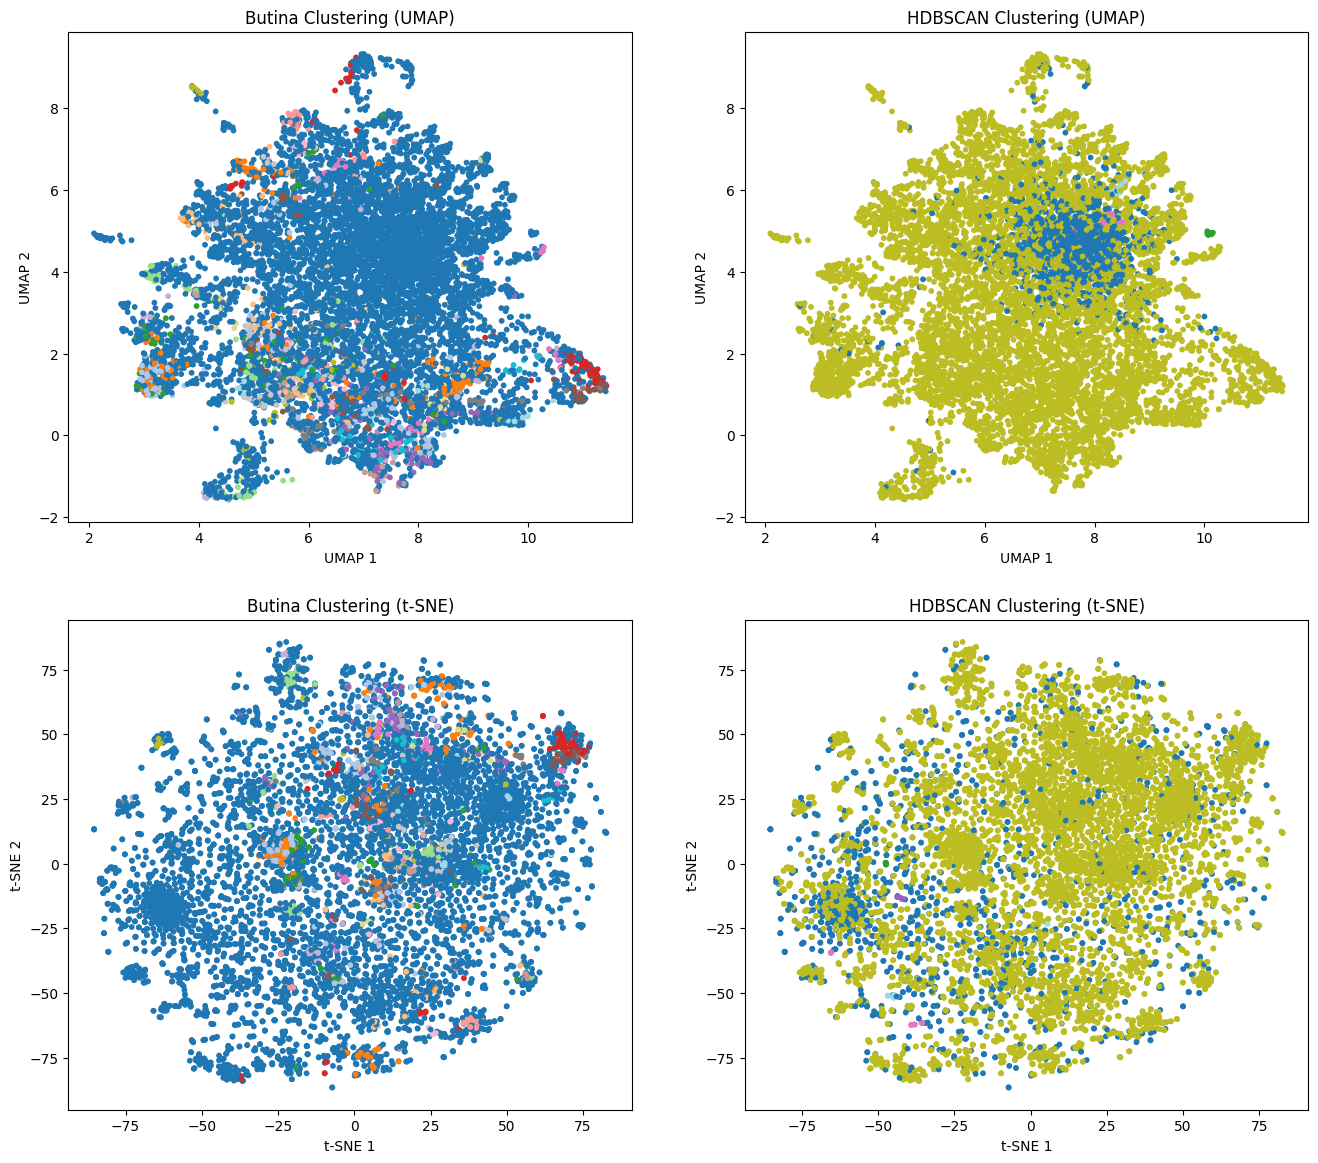

In [177]:
# visualizing the two clustering methods using subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes[0,0].scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=butina_labels, cmap="tab20", s=10)
axes[0,0].set_title("Butina Clustering (UMAP)")
axes[0,0].set_xlabel("UMAP 1")
axes[0,0].set_ylabel("UMAP 2")
axes[0,1].scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=hdbs_labels, cmap="tab20", s=10)
axes[0,1].set_title("HDBSCAN Clustering (UMAP)")
axes[0,1].set_xlabel("UMAP 1")
axes[0,1].set_ylabel("UMAP 2")
axes[1,0].scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=butina_labels, cmap="tab20", s=10)
axes[1,0].set_title("Butina Clustering (t-SNE)")
axes[1,0].set_xlabel("t-SNE 1")
axes[1,0].set_ylabel("t-SNE 2")
axes[1,1].scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=hdbs_labels, cmap="tab20", s=10)
axes[1,1].set_title("HDBSCAN Clustering (t-SNE)")
axes[1,1].set_xlabel("t-SNE 1")
axes[1,1].set_ylabel("t-SNE 2")


plt.show()

In [178]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!

fp_list = df_pubchem["fingerprint"].tolist()
dists = []
nfps = len(fp_list)

for i in range(1, nfps):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.4  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters))

Number of clusters: 336


In [179]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in butina_clusters if len(c) >= 10]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 18
mean size: 97.5
max size: 1086
singletons: 0


In [180]:
# use HDBSCAN for clustering
hdbs_clustering = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="euclidean"
)

hdbs_labels = hdbs_clustering.fit_predict(fp_list)
# print("Number of DBSCAN clusters:",
#       len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
# print("Noise points:", list(hdbs_labels).count(-1))

In [181]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
print("Noise points:", list(hdbs_labels).count(-1))

Number of DBSCAN clusters: 34
Noise points: 892


In [182]:
# convert fingerprints to numpy
X = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fp_list):
    DataStructs.ConvertToNumpyArray(fp, X[i])

In [183]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding = umap_model.fit_transform(X)

/Users/hugopeeters/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/hugopeeters/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [184]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding = tsne_model.fit_transform(X)

Text(0, 0.5, 't-SNE 2')

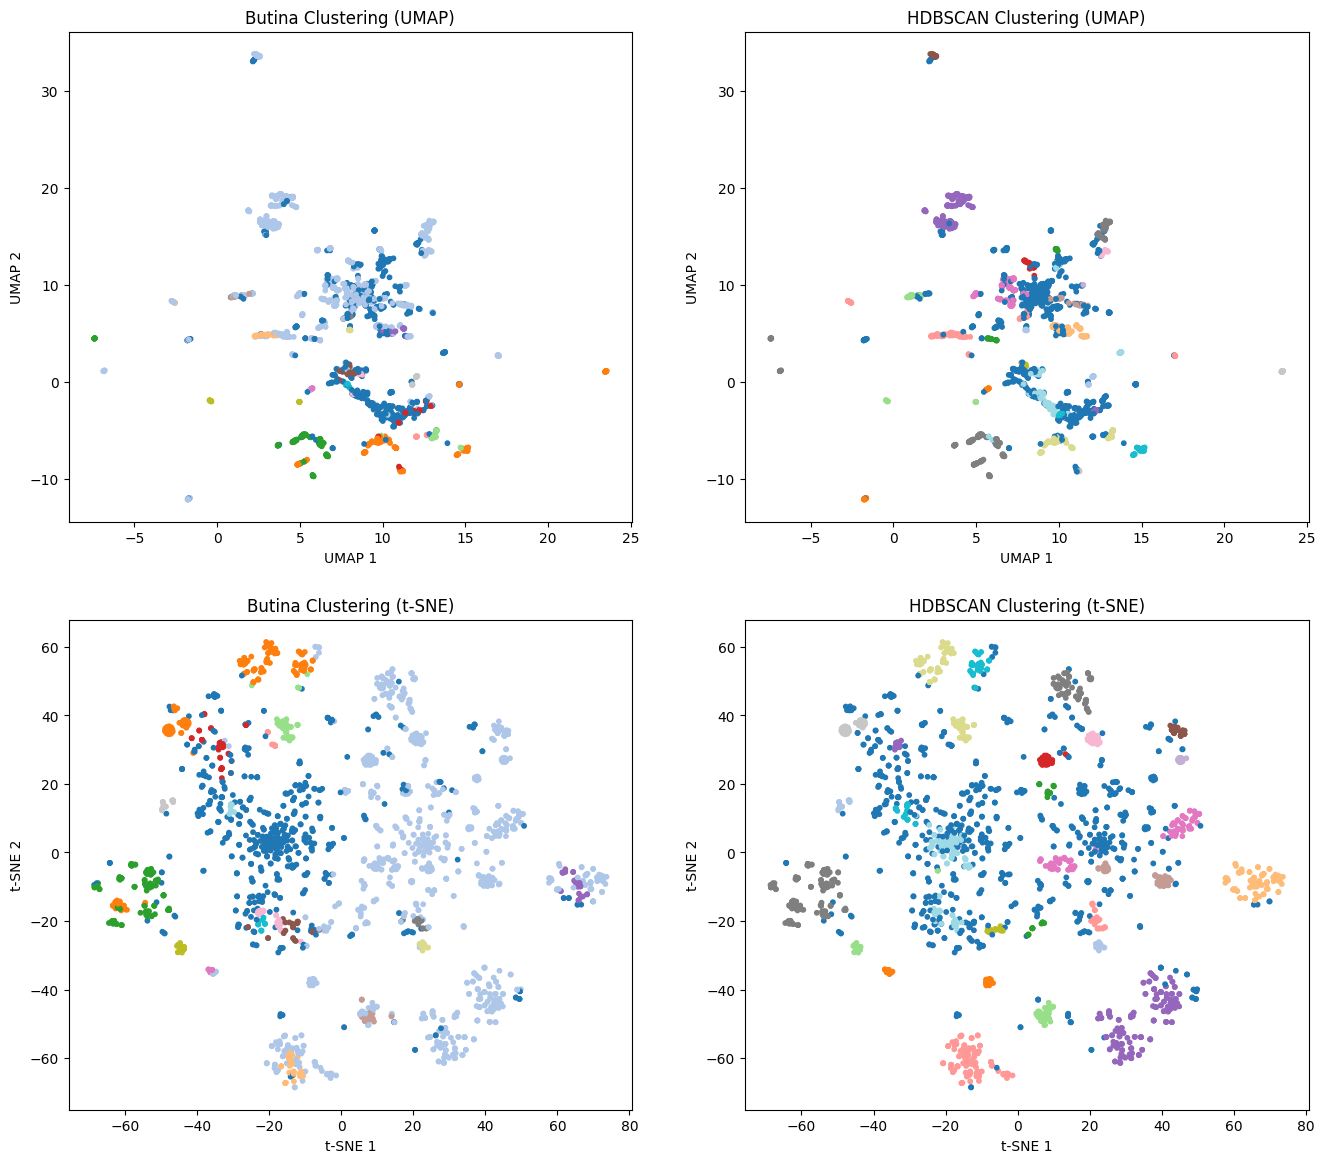

In [185]:
# visualizing the two clustering methods using subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes[0,0].scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=butina_labels, cmap="tab20", s=10)
axes[0,0].set_title("Butina Clustering (UMAP)")
axes[0,0].set_xlabel("UMAP 1")
axes[0,0].set_ylabel("UMAP 2")
axes[0,1].scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=hdbs_labels, cmap="tab20", s=10)
axes[0,1].set_title("HDBSCAN Clustering (UMAP)")
axes[0,1].set_xlabel("UMAP 1")
axes[0,1].set_ylabel("UMAP 2")
axes[1,0].scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=butina_labels, cmap="tab20", s=10)
axes[1,0].set_title("Butina Clustering (t-SNE)")
axes[1,0].set_xlabel("t-SNE 1")
axes[1,0].set_ylabel("t-SNE 2")
axes[1,1].scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=hdbs_labels, cmap="tab20", s=10)
axes[1,1].set_title("HDBSCAN Clustering (t-SNE)")
axes[1,1].set_xlabel("t-SNE 1")
axes[1,1].set_ylabel("t-SNE 2")

Visualise representative molecules of the three biggest clusters of both methods.

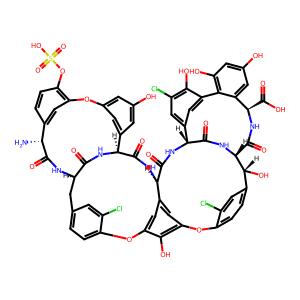

In [186]:
# displaying a molecule from the largest clusters of the Butina clustering

# sorting clusters by size and visualizing the largest cluster
clusters_ordered = sorted(clusters_filtered, key=len, reverse=True)
largest_cluster = clusters_ordered[0]
largest_cluster_mol = Chem.MolFromSmiles(df_pubchem.iloc[largest_cluster[1]]["smiles"])
Draw.MolToImage(largest_cluster_mol)

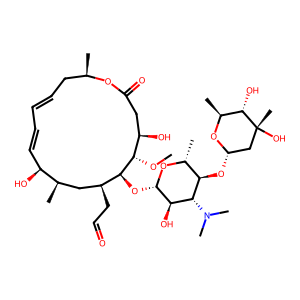

In [187]:
second_largest_cluster = clusters_ordered[1]
second_largest_cluster_mol = Chem.MolFromSmiles(df_pubchem.iloc[second_largest_cluster[0]]["smiles"])
Draw.MolToImage(second_largest_cluster_mol)

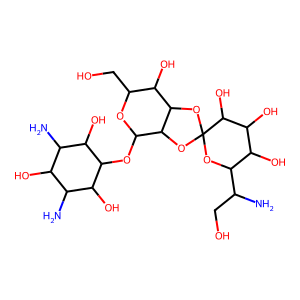

In [188]:
third_largest_cluster = clusters_ordered[2]
third_largest_cluster_mol = Chem.MolFromSmiles(df_pubchem.iloc[third_largest_cluster[1]]["smiles"])
Draw.MolToImage(third_largest_cluster_mol)

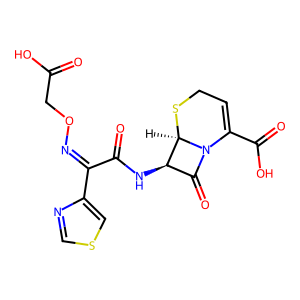

In [ ]:
# THIS WAS DONE BY AI, I HAD NO IDEA HOW TO DO THIS
# displaying a molecule from the largest clusters of the HDBSCAN clustering

# Get unique cluster labels and their sizes
unique_labels, counts = np.unique(hdbs_labels, return_counts=True)
# Sort by size (descending) and remove noise points (label -1)
hdbs_clusters_sorted = sorted(
    [(label, count) for label, count in zip(unique_labels, counts) if label != -1],
    key=lambda x: x[1],
    reverse=True
)

# Get the three largest clusters
largest_hdbs_cluster_label = hdbs_clusters_sorted[0][0]
second_largest_hdbs_cluster_label = hdbs_clusters_sorted[1][0]
third_largest_hdbs_cluster_label = hdbs_clusters_sorted[2][0]

# Get indices for the largest cluster
largest_hdbs_indices = np.where(hdbs_labels == largest_hdbs_cluster_label)[0]
largest_hdbs_cluster_mol = Chem.MolFromSmiles(df_pubchem.iloc[largest_hdbs_indices[0]]["smiles"])
Draw.MolToImage(largest_hdbs_cluster_mol)

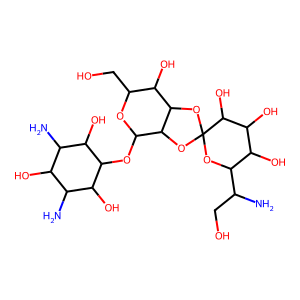

In [193]:
second_largest_hdbs_indices = np.where(hdbs_labels == second_largest_hdbs_cluster_label)[0]
second_largest_hdbs_cluster_mol = Chem.MolFromSmiles(df_pubchem.iloc[second_largest_hdbs_indices[0]]["smiles"])
Draw.MolToImage(second_largest_hdbs_cluster_mol)

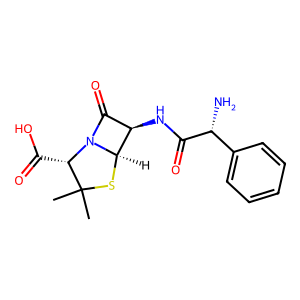

In [195]:
third_largest_hdbs_indices = np.where(hdbs_labels == third_largest_hdbs_cluster_label)[0]
third_largest_hdbs_cluster_mol = Chem.MolFromSmiles(df_pubchem.iloc[third_largest_hdbs_indices[0]]["smiles"])
Draw.MolToImage(third_largest_hdbs_cluster_mol)

In [146]:
hdbs_labels

array([20, -1, 14, ..., 23, 10, -1], shape=(2358,))

In [126]:
clusters_filtered

[(526,
  0,
  2,
  3,
  8,
  10,
  30,
  31,
  34,
  36,
  37,
  42,
  45,
  48,
  49,
  50,
  52,
  53,
  59,
  60,
  62,
  63,
  64,
  65,
  67,
  75,
  80,
  82,
  86,
  89,
  92,
  94,
  95,
  99,
  100,
  101,
  102,
  103,
  104,
  108,
  109,
  110,
  112,
  114,
  115,
  121,
  123,
  124,
  127,
  129,
  131,
  132,
  135,
  136,
  137,
  139,
  140,
  141,
  147,
  152,
  153,
  155,
  157,
  160,
  162,
  164,
  168,
  169,
  170,
  171,
  172,
  174,
  179,
  182,
  193,
  194,
  196,
  201,
  205,
  207,
  209,
  218,
  221,
  222,
  223,
  224,
  228,
  229,
  232,
  236,
  237,
  242,
  243,
  245,
  246,
  250,
  251,
  252,
  253,
  254,
  265,
  268,
  271,
  272,
  273,
  275,
  276,
  279,
  280,
  282,
  283,
  284,
  288,
  293,
  294,
  303,
  311,
  314,
  315,
  316,
  318,
  320,
  321,
  324,
  326,
  327,
  329,
  330,
  331,
  333,
  335,
  336,
  342,
  344,
  345,
  347,
  348,
  351,
  352,
  353,
  356,
  357,
  358,
  360,
  364,
  366,
  368,
  369,
 

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
- The chembl dataset is significantly more broad and is not easy to cluster, while the pubchem dataset can be split up into clear clusters.
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
- Density-based methods detect clusters in dense regions and handle noise well, while similarity-based models group data based on pairwise similarity and work best when similarities between samples are clearly defined.
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
- for the chembl dataset, i was not able to find parameters that improved the clustering, but for the pubchem data, the threshold was set to 0.4, the min_cluster_size to 15 and min_samples to 5.
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
- the umap did not show that well clustering compared to TSNE, but TSNE was able to define good looking clusters.
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
- HDBSCAN and TSNE showed the most well defined clusters.
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
- The runtime for some of the cells was really long, up to 5 minutes sometimes. a way to improve this is to randomly sample from the large dataset to get a representative smaller dataset.
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?
- not really tbh...